# Notebook 01 — CAPM Beta Decomposition (Indian Portfolio)

## Objective
Apply the CAPM single-factor model to a portfolio of Indian equities using the **Nifty 50** as the market proxy. Decompose each stock's risk into **systematic** (market-driven) and **idiosyncratic** (stock-specific) components.

## Portfolio
| Stock | Ticker | Sector |
|---|---|---|
| Reliance Industries | RELIANCE.NS | Energy / Conglomerate |
| Tata Consultancy Services | TCS.NS | IT Services |
| HDFC Bank | HDFCBANK.NS | Banking |
| Infosys | INFY.NS | IT Services |
| ITC | ITC.NS | FMCG |

**Market Proxy:** Nifty 50 (`^NSEI`)

## The Model
$$R_i = \alpha_i + \beta_i \cdot R_m + \epsilon_i$$

## Variance Decomposition
$$\text{Total Variance} = \underbrace{\beta_i^2 \cdot \sigma_m^2}_{\text{Systematic}} + \underbrace{\sigma_{\epsilon_i}^2}_{\text{Idiosyncratic}}$$

## Note on Fama-French
The Fama-French 3-Factor model is **not applied** to this Indian portfolio because official SMB and HML factor data is only available for US markets through Kenneth French's data library. Applying US factors to Indian stocks would be economically incorrect.

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme — applied once globally ───────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor'  : '#0D0D0D',
    'axes.facecolor'    : '#0D0D0D',
    'axes.edgecolor'    : '#444444',
    'axes.labelcolor'   : '#CCCCCC',
    'axes.titlecolor'   : '#FFFFFF',
    'xtick.color'       : '#AAAAAA',
    'ytick.color'       : '#AAAAAA',
    'grid.color'        : '#2A2A2A',
    'grid.linewidth'    : 0.6,
    'legend.facecolor'  : '#1A1A1A',
    'legend.edgecolor'  : '#444444',
    'legend.labelcolor' : '#CCCCCC',
    'text.color'        : '#FFFFFF',
    'font.size'         : 10,
})

# ── Portfolio Configuration ───────────────────────────────────────────────────
TICKERS      = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ITC.NS']
LABELS       = ['RELIANCE', 'TCS', 'HDFCBANK', 'INFY', 'ITC']
MARKET       = '^NSEI'
START        = '2018-01-01'
END          = '2024-01-01'

COLORS       = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300']
STOCK_COLORS = dict(zip(LABELS, COLORS))

print(f"Portfolio : {LABELS}")
print(f"Market    : Nifty 50 ({MARKET})")
print(f"Period    : {START} → {END}")

Portfolio : ['RELIANCE', 'TCS', 'HDFCBANK', 'INFY', 'ITC']
Market    : Nifty 50 (^NSEI)
Period    : 2018-01-01 → 2024-01-01


## 2. Download Data

In [2]:
raw       = yf.download(TICKERS + [MARKET], start=START, end=END)['Close']
prices    = raw[TICKERS].copy()
market_px = raw[MARKET].copy()

prices.columns = LABELS

returns  = np.log(prices / prices.shift(1)).dropna()
mkt_ret  = np.log(market_px / market_px.shift(1)).dropna()

returns, mkt_ret = returns.align(mkt_ret, join='inner', axis=0)

print(f"Data shape : {returns.shape}")
print(f"Date range : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"\nAnnualised Volatility per Stock:")
for col in LABELS:
    print(f"  {col:12s} : {returns[col].std() * np.sqrt(252) * 100:.2f}%")
returns.head()

[*********************100%***********************]  6 of 6 completed

Data shape : (1473, 5)
Date range : 2018-01-03 → 2023-12-29

Annualised Volatility per Stock:
  RELIANCE     : 29.79%
  TCS          : 24.94%
  HDFCBANK     : 25.48%
  INFY         : 28.23%
  ITC          : 25.46%


,RELIANCE,TCS,HDFCBANK,INFY,ITC
Date,,,,,
2018-01-03,0.003998,0.002828,-0.010577,-0.008191,0.001533
2018-01-04,0.005994,0.006967,0.003906,-0.005793,0.001531
2018-01-05,0.003200,0.012009,0.001987,-0.003354,0.005148
2018-01-08,0.005724,0.009327,-0.001611,0.023487,0.010218
2018-01-09,0.013266,-0.001991,0.001665,0.005103,0.018466


## 3. OLS Regression — CAPM Beta & Alpha

In [3]:
def run_capm(stock_returns, market_returns, label):
    mkt       = market_returns.copy()
    mkt.name  = 'market'
    X         = sm.add_constant(mkt)
    model     = sm.OLS(stock_returns, X).fit()
    alpha     = model.params['const']
    beta      = model.params['market']
    r_squared = model.rsquared
    residuals = model.resid
    total_var = stock_returns.var()
    sys_var   = (beta ** 2) * mkt.var()
    idio_var  = residuals.var()
    return {
        'label'     : label,
        'alpha'     : alpha,
        'beta'      : beta,
        'r_squared' : r_squared,
        'total_var' : total_var,
        'sys_var'   : sys_var,
        'idio_var'  : idio_var,
        'sys_pct'   : sys_var  / total_var * 100,
        'idio_pct'  : idio_var / total_var * 100,
        'residuals' : residuals,
        'model'     : model
    }

mkt_series      = mkt_ret.squeeze()
mkt_series.name = 'market'

results = {l: run_capm(returns[l], mkt_series, l) for l in LABELS}

summary = pd.DataFrame({
    'Beta'            : {l: results[l]['beta']      for l in LABELS},
    'Alpha (daily)'   : {l: results[l]['alpha']     for l in LABELS},
    'R²'              : {l: results[l]['r_squared'] for l in LABELS},
    'Systematic %'    : {l: results[l]['sys_pct']   for l in LABELS},
    'Idiosyncratic %' : {l: results[l]['idio_pct']  for l in LABELS},
}).round(4)

print("\n── CAPM Regression Summary — Indian Portfolio ───────────────")
print(summary.to_string())


── CAPM Regression Summary — Indian Portfolio ───────────────
            Beta  Alpha (daily)      R²  Systematic %  Idiosyncratic %
RELIANCE  1.1023         0.0002  0.4615       46.1491          53.8509
TCS       0.6911         0.0004  0.2588       25.8772          74.1228
HDFCBANK  1.0528        -0.0001  0.5753       57.5298          42.4702
INFY      0.8315         0.0004  0.2924       29.2433          70.7567
ITC       0.7172         0.0002  0.2675       26.7479          73.2521


## 4. Visualisations

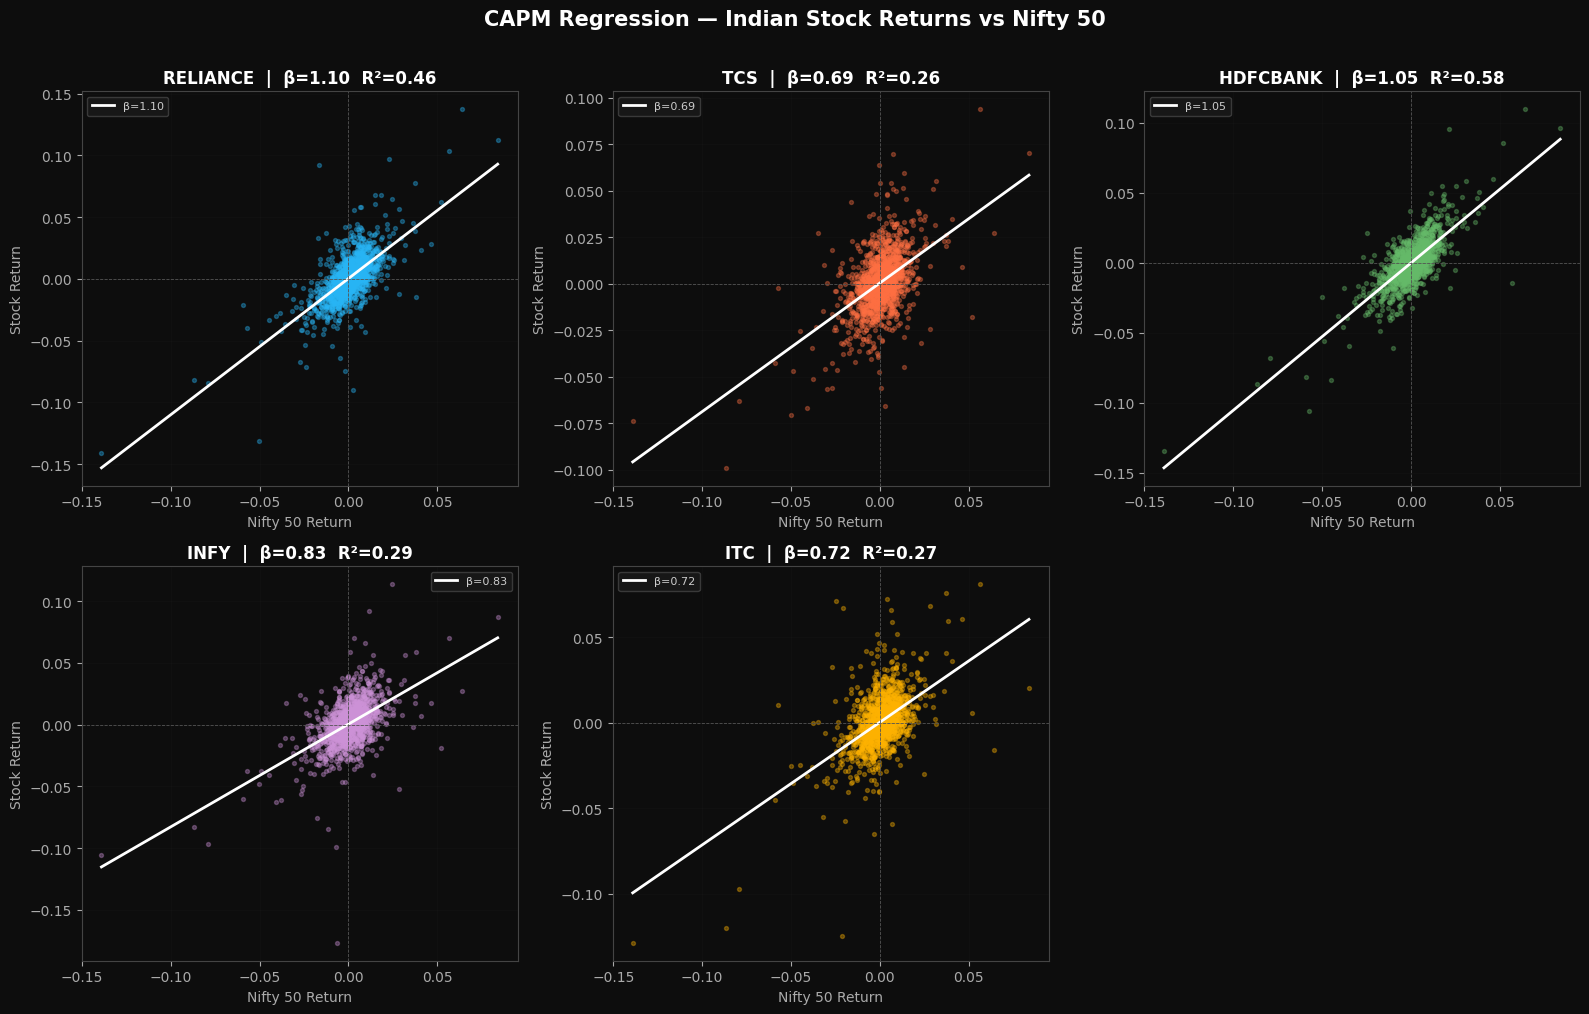

In [4]:
# ── Plot 1: Scatter — each stock vs Nifty 50 ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes      = axes.flatten()
fig.suptitle('CAPM Regression — Indian Stock Returns vs Nifty 50',
             fontsize=15, fontweight='bold', y=1.01, color='white')
fig.patch.set_facecolor('#0D0D0D')

for i, label in enumerate(LABELS):
    ax  = axes[i]
    res = results[label]
    x   = mkt_series.values
    y   = returns[label].values

    ax.scatter(x, y, alpha=0.35, s=8, color=STOCK_COLORS[label])

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = res['alpha'] + res['beta'] * x_line
    ax.plot(x_line, y_line, color='white', linewidth=2,
            label=f"β={res['beta']:.2f}")

    ax.axhline(0, color='#555555', linewidth=0.6, linestyle='--')
    ax.axvline(0, color='#555555', linewidth=0.6, linestyle='--')
    ax.set_title(f"{label}  |  β={res['beta']:.2f}  R²={res['r_squared']:.2f}",
                 fontweight='bold', color='white')
    ax.set_xlabel('Nifty 50 Return', color='#AAAAAA')
    ax.set_ylabel('Stock Return',    color='#AAAAAA')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.15)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


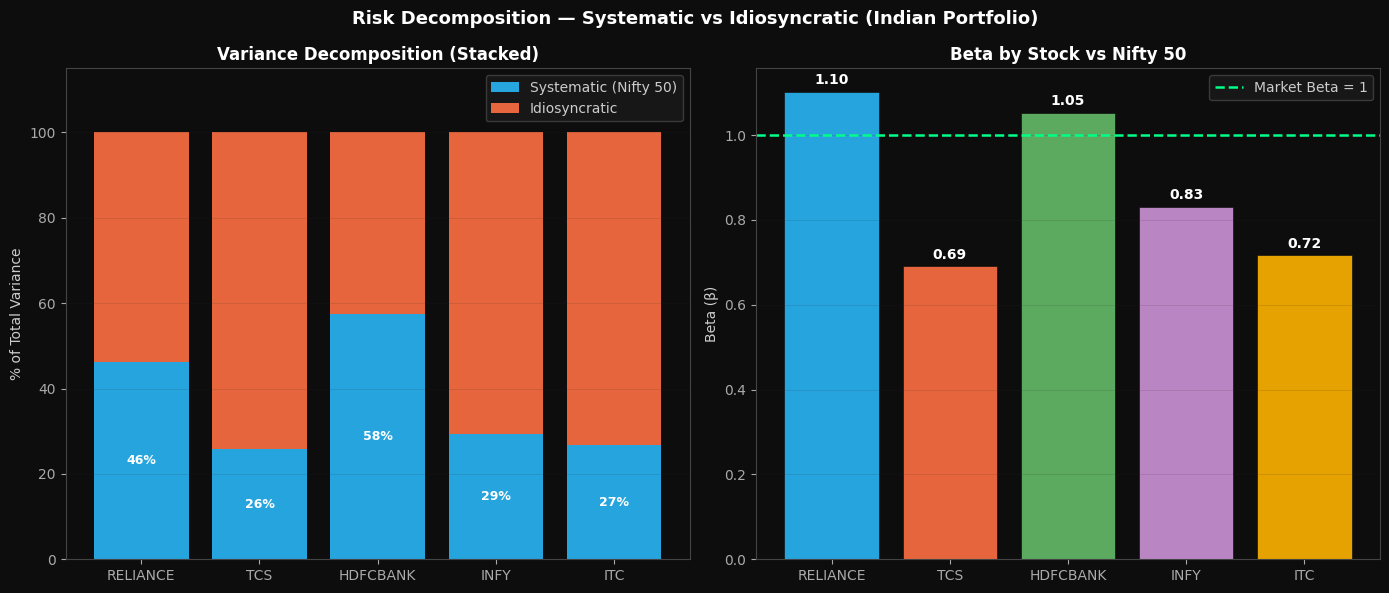

In [5]:
# ── Plot 2: Variance decomposition + Beta ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Risk Decomposition — Systematic vs Idiosyncratic (Indian Portfolio)',
             fontsize=13, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

sys_pcts   = [results[l]['sys_pct']  for l in LABELS]
idio_pcts  = [results[l]['idio_pct'] for l in LABELS]
betas      = [results[l]['beta']     for l in LABELS]
bar_colors = [STOCK_COLORS[l]        for l in LABELS]

# Stacked variance decomposition
ax    = axes[0]
bars1 = ax.bar(LABELS, sys_pcts,  color='#29B6F6',
               label='Systematic (Nifty 50)', alpha=0.9)
bars2 = ax.bar(LABELS, idio_pcts, bottom=sys_pcts,
               color='#FF7043', label='Idiosyncratic', alpha=0.9)
ax.set_ylabel('% of Total Variance', color='#CCCCCC')
ax.set_title('Variance Decomposition (Stacked)', fontweight='bold', color='white')
ax.legend()
ax.set_ylim(0, 115)
ax.grid(True, axis='y', alpha=0.15)
for bar, v in zip(bars1, sys_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, v/2,
            f'{v:.0f}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=9)

# Beta comparison
ax2  = axes[1]
bars = ax2.bar(LABELS, betas, color=bar_colors,
               alpha=0.9, edgecolor='#0D0D0D', linewidth=0.5)
ax2.axhline(1.0, color='#00FF88', linewidth=1.8,
            linestyle='--', label='Market Beta = 1')
ax2.set_ylabel('Beta (β)', color='#CCCCCC')
ax2.set_title('Beta by Stock vs Nifty 50', fontweight='bold', color='white')
ax2.legend()
ax2.grid(True, axis='y', alpha=0.15)
for bar, v in zip(bars, betas):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f'{v:.2f}', ha='center', va='bottom',
             fontweight='bold', fontsize=10, color='white')

plt.tight_layout()
plt.show()


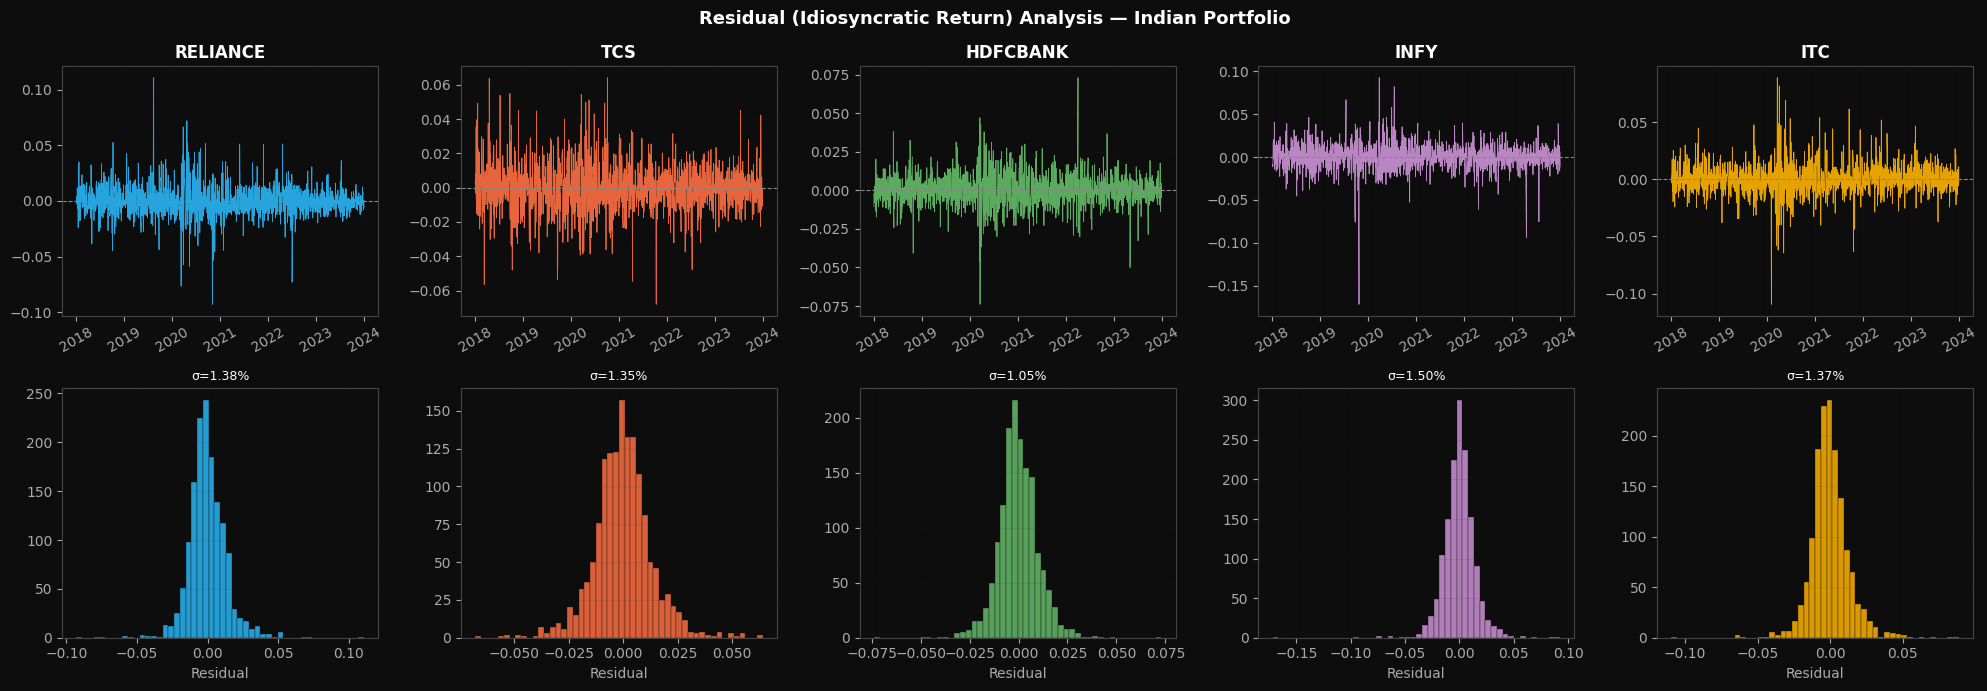

In [6]:
# ── Plot 3: Residual analysis ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('Residual (Idiosyncratic Return) Analysis — Indian Portfolio',
             fontsize=13, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

for i, label in enumerate(LABELS):
    resid  = results[label]['residuals']

    ax_top = axes[0][i]
    ax_top.plot(resid.index, resid.values,
                color=STOCK_COLORS[label], linewidth=0.6, alpha=0.9)
    ax_top.axhline(0, color='#888888', linewidth=0.8, linestyle='--')
    ax_top.set_title(f'{label}', fontweight='bold', color='white')
    ax_top.tick_params(axis='x', rotation=30)
    ax_top.grid(True, alpha=0.12)

    ax_bot = axes[1][i]
    ax_bot.hist(resid, bins=50, color=STOCK_COLORS[label],
                alpha=0.85, edgecolor='#0D0D0D', linewidth=0.3)
    ax_bot.set_title(f'σ={resid.std()*100:.2f}%', fontsize=9, color='white')
    ax_bot.set_xlabel('Residual', color='#AAAAAA')
    ax_bot.grid(True, alpha=0.12)

plt.tight_layout()
plt.show()


## 5. US vs India Comparison

In [7]:
# US portfolio results from Notebook 01 US
us_avg_beta  = (1.22 + 1.09 + 0.89 + 0.55 + 1.13) / 5
us_avg_idio  = (36.4 + 45.2 + 68.1 + 68.5 + 56.4) / 5
us_avg_r2    = (0.636 + 0.548 + 0.319 + 0.315 + 0.436) / 5

india_avg_beta = np.mean([results[l]['beta']      for l in LABELS])
india_avg_idio = np.mean([results[l]['idio_pct']  for l in LABELS])
india_avg_r2   = np.mean([results[l]['r_squared'] for l in LABELS])

comparison = pd.DataFrame({
    'Avg Beta'        : [us_avg_beta,  india_avg_beta],
    'Avg R²'          : [us_avg_r2,    india_avg_r2],
    'Avg Idiosync. %' : [us_avg_idio,  india_avg_idio],
}, index=['US Portfolio (S&P 500)', 'India Portfolio (Nifty 50)']).round(3)

print("── US vs India Portfolio Comparison ─────────────────────────")
print(comparison.to_string())
print("\nInterpretation:")
print("  Higher avg idiosyncratic % in India → stock-specific risk")
print("  dominates more in Indian markets than in US markets.")
print("  Lower avg R² → Nifty 50 explains less of individual stock")
print("  movements than S&P 500 does for US stocks.")

── US vs India Portfolio Comparison ─────────────────────────
                            Avg Beta  Avg R²  Avg Idiosync. %
US Portfolio (S&P 500)         0.976   0.451           54.920
India Portfolio (Nifty 50)     0.879   0.371           62.891

Interpretation:
  Higher avg idiosyncratic % in India → stock-specific risk
  dominates more in Indian markets than in US markets.
  Lower avg R² → Nifty 50 explains less of individual stock
  movements than S&P 500 does for US stocks.


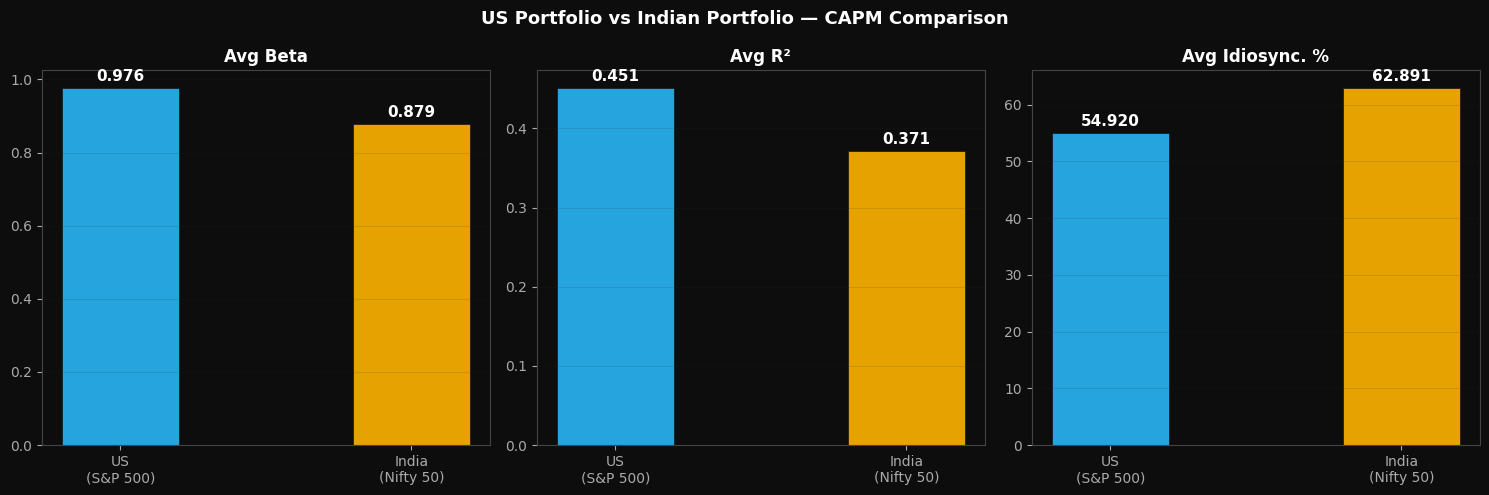

In [8]:
# ── Plot 4: US vs India comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('US Portfolio vs Indian Portfolio — CAPM Comparison',
             fontsize=13, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

metrics = ['Avg Beta', 'Avg R²', 'Avg Idiosync. %']
us_vals = [us_avg_beta, us_avg_r2, us_avg_idio]
in_vals = [india_avg_beta, india_avg_r2, india_avg_idio]

for ax, metric, us_v, in_v in zip(axes, metrics, us_vals, in_vals):
    bars = ax.bar(
        ['US\n(S&P 500)', 'India\n(Nifty 50)'],
        [us_v, in_v],
        color=['#29B6F6', '#FFB300'], alpha=0.9,
        edgecolor='#0D0D0D', linewidth=0.5, width=0.4
    )
    ax.set_title(metric, fontweight='bold', color='white')
    ax.grid(True, axis='y', alpha=0.15)
    for bar, v in zip(bars, [us_v, in_v]):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + max(us_v, in_v) * 0.02,
                f'{v:.3f}', ha='center',
                fontweight='bold', fontsize=11, color='white')

plt.tight_layout()
plt.show()


## 6. Key Findings

In [9]:
print("=" * 62)
print("  CAPM DECOMPOSITION — INDIAN PORTFOLIO KEY FINDINGS")
print("=" * 62)

for label in LABELS:
    r     = results[label]
    style = 'aggressive' if r['beta'] > 1 else 'defensive'
    print(f"\n{label}")
    print(f"  Beta            : {r['beta']:.3f}  ({style})")
    print(f"  Alpha (daily)   : {r['alpha']*100:.4f}%")
    print(f"  R²              : {r['r_squared']:.3f}")
    print(f"  Systematic risk : {r['sys_pct']:.1f}%")
    print(f"  Idiosync. risk  : {r['idio_pct']:.1f}%")

print("\n" + "=" * 62)
highest_beta = max(LABELS, key=lambda l: results[l]['beta'])
lowest_beta  = min(LABELS, key=lambda l: results[l]['beta'])
most_idio    = max(LABELS, key=lambda l: results[l]['idio_pct'])
most_sys     = max(LABELS, key=lambda l: results[l]['sys_pct'])
print(f"  Most market-sensitive : {highest_beta} (β={results[highest_beta]['beta']:.2f})")
print(f"  Most defensive        : {lowest_beta}  (β={results[lowest_beta]['beta']:.2f})")
print(f"  Most idiosyncratic    : {most_idio}  ({results[most_idio]['idio_pct']:.1f}% idio.)")
print(f"  Most market-driven    : {most_sys}  ({results[most_sys]['sys_pct']:.1f}% sys.)")
print("\n  Key Insight:")
print("  Indian IT stocks (TCS, INFY) have high idiosyncratic risk")
print("  because their revenues are USD-denominated — driven by")
print("  global tech demand, not the domestic Nifty 50 market.")
print("=" * 62)

  CAPM DECOMPOSITION — INDIAN PORTFOLIO KEY FINDINGS

RELIANCE
  Beta            : 1.102  (aggressive)
  Alpha (daily)   : 0.0249%
  R²              : 0.461
  Systematic risk : 46.1%
  Idiosync. risk  : 53.9%

TCS
  Beta            : 0.691  (defensive)
  Alpha (daily)   : 0.0438%
  R²              : 0.259
  Systematic risk : 25.9%
  Idiosync. risk  : 74.1%

HDFCBANK
  Beta            : 1.053  (aggressive)
  Alpha (daily)   : -0.0104%
  R²              : 0.575
  Systematic risk : 57.5%
  Idiosync. risk  : 42.5%

INFY
  Beta            : 0.831  (defensive)
  Alpha (daily)   : 0.0428%
  R²              : 0.292
  Systematic risk : 29.2%
  Idiosync. risk  : 70.8%

ITC
  Beta            : 0.717  (defensive)
  Alpha (daily)   : 0.0186%
  R²              : 0.267
  Systematic risk : 26.7%
  Idiosync. risk  : 73.3%

  Most market-sensitive : RELIANCE (β=1.10)
  Most defensive        : TCS  (β=0.69)
  Most idiosyncratic    : TCS  (74.1% idio.)
  Most market-driven    : HDFCBANK  (57.5% sys.)

  K